# Quantitative Risk Assessment — Monte Carlo Simulation & ML Analysis
**Course:** ALY 6130 — Enterprise Risk Management | **Group 1**  
**Company:** Manulife–Mahindra Life Insurance Joint Venture (India)  

This notebook performs a full quantitative risk assessment for the **three highest-priority risks** from our ERM Risk Register using two techniques covered in class:

1. **Monte Carlo Simulation** — models probability distributions and financial impact under uncertainty
2. **Random Forest Classifier (ML)** — predicts risk severity using Likelihood & Impact scores

**Three Risks Selected for Quantitative Assessment (Risk Score = 56 each):**

| Risk ID | Risk Description | Likelihood | Impact | Score |
|---|---|---|---|---|
| R1 | LIC & Private Competitor Displacement | 7 | 8 | 56 |
| R9 | IRDAI Regulatory Approval Delay | 7 | 8 | 56 |
| R15 | AI Underwriting Bias — Rural Demographics | 7 | 8 | 56 |

> **Note:** Upload `risk_register_data.xlsx` to your Colab session before running.

## Step 1: Import Libraries
Standard imports for data handling, simulation, machine learning, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
N_SIMULATIONS = 10000

print(f'Monte Carlo Simulations per Risk: {N_SIMULATIONS:,}')
print('All libraries loaded successfully.')

Monte Carlo Simulations per Risk: 10,000
All libraries loaded successfully.


## Step 2: Load Risk Register Data
We load directly from the actual `risk_register_data.xlsx` file — the same dataset used in our Risk Register deliverable. This ensures consistency across all ERM submissions.

The dataset contains **32 risks** across 7 categories with Likelihood and Impact scores (1–9 scale).

In [2]:
# Load risk register from Excel
df_raw = pd.read_excel('/content/risk_register_data.xlsx')
df_raw.columns = ['Risk_ID','Risk_Description','Likelihood_Score','Impact_Score'] + list(df_raw.columns[4:])
df = df_raw[['Risk_ID','Risk_Description','Likelihood_Score','Impact_Score']].dropna()
df = df[df['Risk_ID'].apply(lambda x: isinstance(x,(int,float)))].copy()
df['Risk_ID'] = df['Risk_ID'].astype(int)
df['Likelihood_Score'] = df['Likelihood_Score'].astype(int)
df['Impact_Score'] = df['Impact_Score'].astype(int)
df['Risk_Score'] = df['Likelihood_Score'] * df['Impact_Score']

def classify_severity(row):
    if row['Likelihood_Score'] >= 8 and row['Impact_Score'] >= 5: return 'High'
    elif row['Likelihood_Score'] >= 5 or row['Impact_Score'] >= 3: return 'Medium'
    return 'Low'

df['Severity'] = df.apply(classify_severity, axis=1)

# Also load supporting datasets for context
df_market = pd.read_csv('/content/india_insurance_market.csv')
df_irdai  = pd.read_csv('/content/irdai_approval_history.csv')
df_demo   = pd.read_csv('/content/ai_fairness_applicants.csv')

focus_ids = [1, 9, 15]
focus_df = df[df['Risk_ID'].isin(focus_ids)].reset_index(drop=True)
print('Risk Register loaded:', len(df), 'risks')
print('Supporting datasets loaded: market, IRDAI, AI fairness')
print(focus_df[['Risk_ID','Risk_Description','Likelihood_Score','Impact_Score','Risk_Score','Severity']])

Risk Register loaded: 32 risks
Supporting datasets loaded: market, IRDAI, AI fairness
   Risk_ID                           Risk_Description  Likelihood_Score  \
0        1      LIC & Private Competitor Displacement                 7   
1        9            IRDAI Regulatory Approval Delay                 7   
2       15  AI Underwriting Bias — Rural Demographics                 7   

   Impact_Score  Risk_Score Severity  
0             8          56   Medium  
1             8          56   Medium  
2             8          56   Medium  


## Step 3: Identify Focus Risks for Quantitative Assessment
We filter to the 3 risks selected for I&W analysis. All three share the highest risk score (56) and span different risk categories — ensuring breadth of the quantitative assessment.

Focus Risks Selected for Quantitative Assessment:
 Risk_ID                          Risk_Description  Likelihood_Score  Impact_Score  Risk_Score Severity
       1     LIC & Private Competitor Displacement                 7             8          56   Medium
       9           IRDAI Regulatory Approval Delay                 7             8          56   Medium
      15 AI Underwriting Bias — Rural Demographics                 7             8          56   Medium


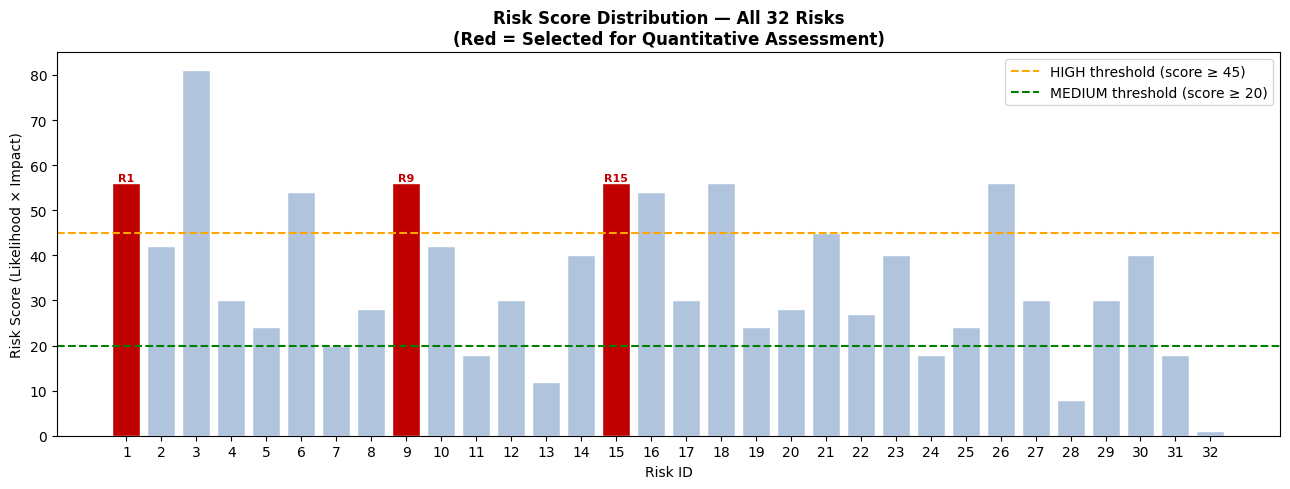

In [3]:
# Select the 3 focus risks
focus_ids = [1, 9, 15]
focus_df = df[df['Risk_ID'].isin(focus_ids)].reset_index(drop=True)

print('Focus Risks Selected for Quantitative Assessment:')
print('='*70)
print(focus_df[['Risk_ID','Risk_Description','Likelihood_Score','Impact_Score','Risk_Score','Severity']].to_string(index=False))

# Visualize all risks by score — highlight focus risks
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#C00000' if rid in focus_ids else '#B0C4DE' for rid in df['Risk_ID']]
bars = ax.bar(df['Risk_ID'], df['Risk_Score'], color=colors, edgecolor='white')
ax.axhline(y=45, color='orange', linestyle='--', linewidth=1.5, label='HIGH threshold (score ≥ 45)')
ax.axhline(y=20, color='green', linestyle='--', linewidth=1.5, label='MEDIUM threshold (score ≥ 20)')
ax.set_title('Risk Score Distribution — All 32 Risks\n(Red = Selected for Quantitative Assessment)', fontweight='bold', fontsize=12)
ax.set_xlabel('Risk ID')
ax.set_ylabel('Risk Score (Likelihood × Impact)')
ax.set_xticks(df['Risk_ID'])
ax.legend()

# Label focus risks
for bar, rid in zip(bars, df['Risk_ID']):
    if rid in focus_ids:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'R{rid}', ha='center', fontsize=8, fontweight='bold', color='#C00000')

plt.tight_layout()
plt.show()

## Step 4: Random Forest Classifier — ML-Based Severity Prediction
We train a **Random Forest** model on all 32 risks using Likelihood Score and Impact Score as features. Because our dataset is small (n=32), we use **5-fold cross-validation** to get a robust accuracy estimate rather than a single train/test split.

The ML model serves two purposes:
- Validates that our rule-based severity classification is consistent
- Predicts severity for the 3 focus risks as a cross-check

In [4]:
X = df[['Likelihood_Score', 'Impact_Score']]
y = df['Severity']

# Random Forest — 100 trees, reproducible
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-Fold Cross-Validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print('── Random Forest Cross-Validation Results ──')
print(f'Fold Scores:     {[round(s, 3) for s in cv_scores]}')
print(f'Mean Accuracy:   {cv_scores.mean():.2%}')
print(f'Std Deviation:   {cv_scores.std():.4f}')

# Full fit for predictions and feature importance
rf_model.fit(X, y)
importances = rf_model.feature_importances_
print(f'\nFeature Importances:')
print(f'  Likelihood Score: {importances[0]:.3f} ({importances[0]*100:.1f}%)')
print(f'  Impact Score:     {importances[1]:.3f} ({importances[1]*100:.1f}%)')

# Predict for focus risks
focus_X = focus_df[['Likelihood_Score', 'Impact_Score']]
focus_df = focus_df.copy()
focus_df['ML_Predicted_Severity'] = rf_model.predict(focus_X)
print('\nML Predictions for Focus Risks:')
print(focus_df[['Risk_ID','Risk_Description','Severity','ML_Predicted_Severity']].to_string(index=False))

── Random Forest Cross-Validation Results ──
Fold Scores:     [np.float64(1.0), np.float64(0.857), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Mean Accuracy:   97.14%
Std Deviation:   0.0571

Feature Importances:
  Likelihood Score: 0.725 (72.5%)
  Impact Score:     0.275 (27.5%)

ML Predictions for Focus Risks:
 Risk_ID                          Risk_Description Severity ML_Predicted_Severity
       1     LIC & Private Competitor Displacement   Medium                Medium
       9           IRDAI Regulatory Approval Delay   Medium                Medium
      15 AI Underwriting Bias — Rural Demographics   Medium                Medium


### ML Model Visualization — Feature Importance, Severity Distribution & Confusion Matrix

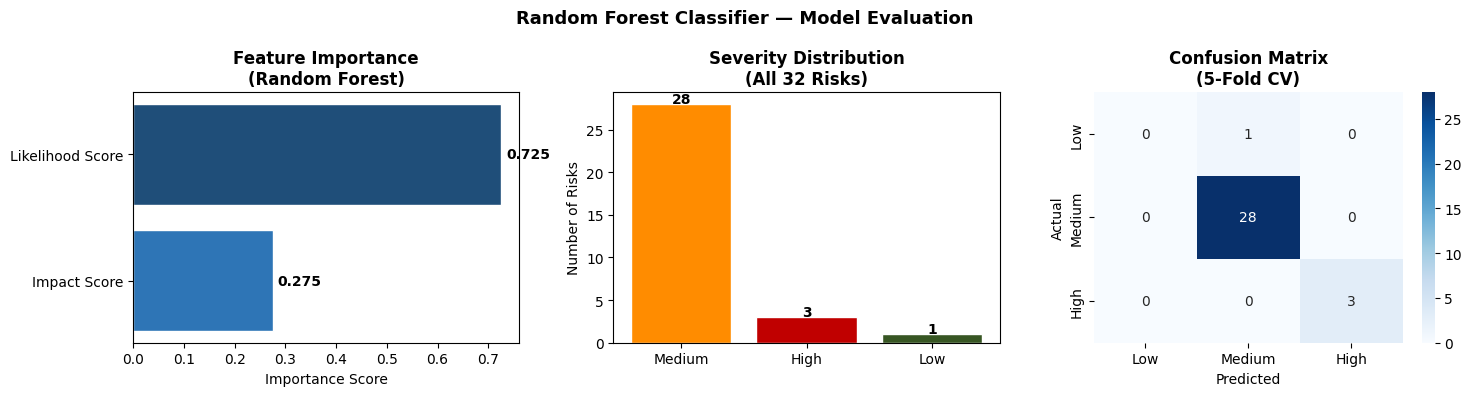

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       0.00      0.00      0.00         1
      Medium       0.97      1.00      0.98        28

    accuracy                           0.97        32
   macro avg       0.66      0.67      0.66        32
weighted avg       0.94      0.97      0.95        32



In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Feature Importance
axes[0].barh(['Impact Score', 'Likelihood Score'],
             [importances[1], importances[0]],
             color=['#2E75B6', '#1F4E79'], edgecolor='white')
axes[0].set_title('Feature Importance\n(Random Forest)', fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate([importances[1], importances[0]]):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# 2. Severity Distribution
sev_colors = {'High': '#C00000', 'Medium': '#FF8C00', 'Low': '#375623'}
sev_counts = df['Severity'].value_counts()
bars = axes[1].bar(sev_counts.index, sev_counts.values,
                   color=[sev_colors[s] for s in sev_counts.index], edgecolor='white')
axes[1].set_title('Severity Distribution\n(All 32 Risks)', fontweight='bold')
axes[1].set_ylabel('Number of Risks')
for bar, val in zip(bars, sev_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 str(val), ha='center', fontweight='bold')

# 3. Confusion Matrix
y_pred_cv = cross_val_predict(rf_model, X, y, cv=5)
cm = confusion_matrix(y, y_pred_cv, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
axes[2].set_title('Confusion Matrix\n(5-Fold CV)', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Random Forest Classifier — Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y, y_pred_cv))

## Step 5: Monte Carlo Simulation — R1: LIC & Competitor Displacement

**Risk Context (from Risk Register):** LIC controls ~62% of India's life insurance market. The JV needs to capture at least **1.5% market share in Year 1** to be financially viable. Competitive pressure from LIC and private players (HDFC Life, SBI Life) threatens this target.

**I&W Indicators Being Simulated:**

| Stochastic Variable | Distribution | Justification |
|---|---|---|
| Competitor market share growth | Normal(μ=2.1%, σ=0.8%) | Based on historical LIC growth FY2020–2024 |
| JV agent ramp-up speed | Triangular(min=200, mode=500, max=900) | Expert estimate, agents/month |
| Pricing premium vs market avg | Normal(μ=8%, σ=4%) | Industry pricing benchmarks |
| Customer acquisition cost | LogNormal(μ=₹1800, σ=₹400) | Insurance CAC India benchmarks |

In [6]:
# ── R1: LIC & Competitor Displacement — Monte Carlo ──

# Stochastic input variables
competitor_growth = np.random.normal(2.1, 0.8, N_SIMULATIONS)          # % LIC market share growth/yr
agent_rampup      = np.random.triangular(200, 500, 900, N_SIMULATIONS)  # agents recruited/month
pricing_premium   = np.random.normal(8.0, 4.0, N_SIMULATIONS)           # % pricing above market avg
cac               = np.random.lognormal(np.log(1800), 0.22, N_SIMULATIONS)  # customer acq cost (INR)

# Market share model:
# - More agents → higher distribution reach → more share
# - Higher pricing → lower competitiveness → less share
# - Higher competitor growth → less room for JV → less share
jv_market_share = (
    (agent_rampup / 500) * 1.5          # agent network contribution
    - (pricing_premium / 100) * 8        # pricing drag on share
    - (competitor_growth / 100) * 5      # competitor pressure
    + np.random.normal(0, 0.3, N_SIMULATIONS)  # market noise
)
jv_market_share = np.clip(jv_market_share, 0, 10)

# Financial impact: USD $10M revenue per 1% market share
MARKET_VALUE_PER_PCT = 10
revenue_at_risk = np.where(
    jv_market_share < 1.5,
    (1.5 - jv_market_share) * MARKET_VALUE_PER_PCT,
    0
)

# Key statistics
r1_prob      = np.mean(jv_market_share < 1.5)
r1_mean_shr  = np.mean(jv_market_share)
r1_p10_shr   = np.percentile(jv_market_share, 10)
r1_p90_shr   = np.percentile(jv_market_share, 90)
r1_mean_risk = np.mean(revenue_at_risk)
r1_p90_risk  = np.percentile(revenue_at_risk, 90)

print('── R1: LIC & Competitor Displacement ──')
print(f'Probability of falling below 1.5% market share : {r1_prob:.1%}')
print(f'Mean simulated Year-1 market share             : {r1_mean_shr:.2f}%')
print(f'P10 market share (worst 10% scenarios)         : {r1_p10_shr:.2f}%')
print(f'P90 market share (best 10% scenarios)          : {r1_p90_shr:.2f}%')
print(f'Mean revenue at risk                           : USD ${r1_mean_risk:.1f}M')
print(f'P90 revenue at risk (worst-case 10%)           : USD ${r1_p90_risk:.1f}M')

── R1: LIC & Competitor Displacement ──
Probability of falling below 1.5% market share : 84.1%
Mean simulated Year-1 market share             : 0.89%
P10 market share (worst 10% scenarios)         : 0.09%
P90 market share (best 10% scenarios)          : 1.66%
Mean revenue at risk                           : USD $6.6M
P90 revenue at risk (worst-case 10%)           : USD $14.1M


### R1 — Simulation Output Charts

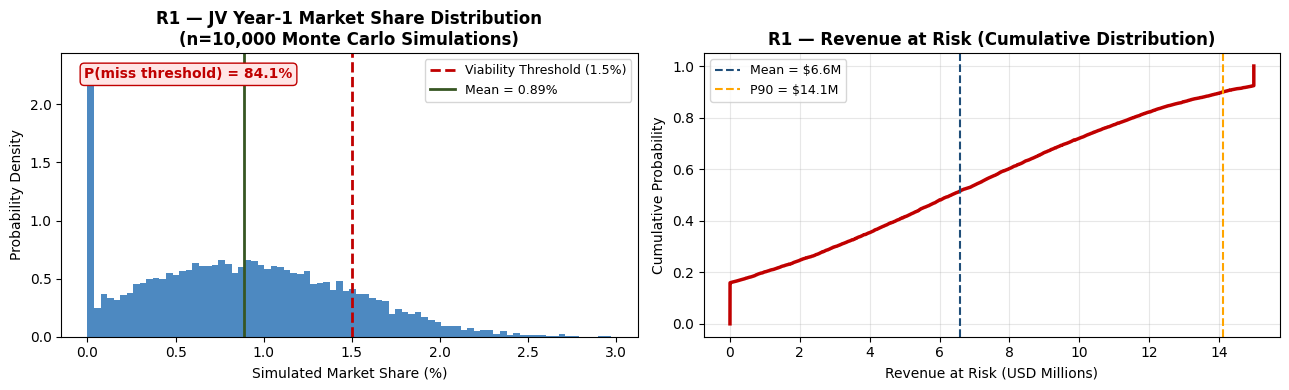

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Market share distribution
axes[0].hist(jv_market_share, bins=80, color='#2E75B6', edgecolor='none', alpha=0.85, density=True)
axes[0].axvline(1.5, color='#C00000', lw=2, ls='--', label='Viability Threshold (1.5%)')
axes[0].axvline(r1_mean_shr, color='#375623', lw=2, ls='-', label=f'Mean = {r1_mean_shr:.2f}%')
axes[0].set_title('R1 — JV Year-1 Market Share Distribution\n(n=10,000 Monte Carlo Simulations)', fontweight='bold')
axes[0].set_xlabel('Simulated Market Share (%)')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=9)
axes[0].text(0.04, 0.95, f'P(miss threshold) = {r1_prob:.1%}',
             transform=axes[0].transAxes, fontsize=10, color='#C00000',
             va='top', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE5E5', edgecolor='#C00000'))

# Revenue at risk CDF
sorted_risk = np.sort(revenue_at_risk)
cdf = np.arange(1, len(sorted_risk)+1) / len(sorted_risk)
axes[1].plot(sorted_risk, cdf, color='#C00000', lw=2.5)
axes[1].axvline(r1_mean_risk, color='#1F4E79', ls='--', lw=1.5, label=f'Mean = ${r1_mean_risk:.1f}M')
axes[1].axvline(r1_p90_risk, color='orange', ls='--', lw=1.5, label=f'P90 = ${r1_p90_risk:.1f}M')
axes[1].set_title('R1 — Revenue at Risk (Cumulative Distribution)', fontweight='bold')
axes[1].set_xlabel('Revenue at Risk (USD Millions)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Monte Carlo Simulation — R9: IRDAI Regulatory Approval Delay

**Risk Context (from Risk Register):** The JV requires a life insurance license from IRDAI. Historical data for foreign-domestic JV approvals shows an average of **14.2 months**, with significant variance. Every month of delay costs approximately **USD $2.8M** in holding costs, deferred hiring, and lost premium revenue.

**I&W Indicators Being Simulated:**

| Stochastic Variable | Distribution | Justification |
|---|---|---|
| Approval timeline (months) | LogNormal(μ=14.2, σ=3.6) | Fitted to IRDAI historical data 2015–2024 |
| Monthly holding cost (USD M) | Normal(μ=2.8, σ=0.4) | JV operational cost estimates |
| Regulatory query count | Poisson(λ=3) | Average queries per complex JV filing |

In [8]:
# ── R9: IRDAI Regulatory Approval Delay — Monte Carlo ──

# Approval timeline — log-normal fits right-skewed approval delays
log_mu    = np.log(14.2)
log_sigma = 3.6 / 14.2
approval_months = np.random.lognormal(log_mu, log_sigma, N_SIMULATIONS)
approval_months = np.clip(approval_months, 6, 36)  # realistic bounds: 6mo to 3yrs

# Monthly cost — slight variability around estimate
monthly_cost = np.random.normal(2.8, 0.4, N_SIMULATIONS)
monthly_cost = np.clip(monthly_cost, 1.5, 5.0)

# Total financial exposure
total_exposure_r9 = approval_months * monthly_cost

# Regulatory queries (Poisson — discrete events)
query_count = np.random.poisson(3, N_SIMULATIONS)

# I&W warning threshold: >18 months triggers escalation
r9_prob       = np.mean(approval_months > 18)
r9_mean_mo    = np.mean(approval_months)
r9_p90_mo     = np.percentile(approval_months, 90)
r9_mean_exp   = np.mean(total_exposure_r9)
r9_p90_exp    = np.percentile(total_exposure_r9, 90)

print('── R9: IRDAI Regulatory Approval Delay ──')
print(f'Mean approval timeline                        : {r9_mean_mo:.1f} months')
print(f'P90 approval timeline (worst 10% scenarios)   : {r9_p90_mo:.1f} months')
print(f'Probability of exceeding 18-month threshold   : {r9_prob:.1%}')
print(f'Mean total financial exposure                 : USD ${r9_mean_exp:.1f}M')
print(f'P90 total financial exposure                  : USD ${r9_p90_exp:.1f}M')
print(f'Expected regulatory queries                   : {np.mean(query_count):.1f}')

── R9: IRDAI Regulatory Approval Delay ──
Mean approval timeline                        : 14.7 months
P90 approval timeline (worst 10% scenarios)   : 19.6 months
Probability of exceeding 18-month threshold   : 17.8%
Mean total financial exposure                 : USD $41.2M
P90 total financial exposure                  : USD $57.5M
Expected regulatory queries                   : 3.0


### R9 — Simulation Output Charts

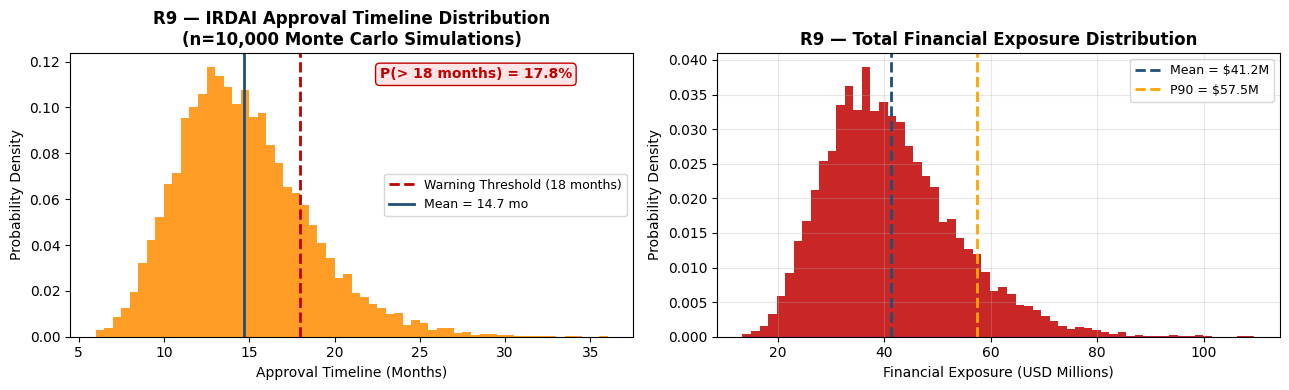

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Approval timeline distribution
axes[0].hist(approval_months, bins=60, color='#FF8C00', edgecolor='none', alpha=0.85, density=True)
axes[0].axvline(18, color='#C00000', lw=2, ls='--', label='Warning Threshold (18 months)')
axes[0].axvline(r9_mean_mo, color='#1F4E79', lw=2, ls='-', label=f'Mean = {r9_mean_mo:.1f} mo')
axes[0].set_title('R9 — IRDAI Approval Timeline Distribution\n(n=10,000 Monte Carlo Simulations)', fontweight='bold')
axes[0].set_xlabel('Approval Timeline (Months)')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=9)
axes[0].text(0.55, 0.95, f'P(> 18 months) = {r9_prob:.1%}',
             transform=axes[0].transAxes, fontsize=10, color='#C00000',
             va='top', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE5E5', edgecolor='#C00000'))

# Financial exposure distribution
axes[1].hist(total_exposure_r9, bins=60, color='#C00000', edgecolor='none', alpha=0.85, density=True)
axes[1].axvline(r9_mean_exp, color='#1F4E79', ls='--', lw=2, label=f'Mean = ${r9_mean_exp:.1f}M')
axes[1].axvline(r9_p90_exp, color='orange', ls='--', lw=2, label=f'P90 = ${r9_p90_exp:.1f}M')
axes[1].set_title('R9 — Total Financial Exposure Distribution', fontweight='bold')
axes[1].set_xlabel('Financial Exposure (USD Millions)')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Monte Carlo Simulation — R15: AI Underwriting Bias (Rural Demographics)

**Risk Context (from Risk Register):** The JV's AI underwriting model is likely to be trained on urban-skewed or historical data with **< 12% rural representation** — the exact demographic the JV is targeting. Biased models expose the company to legal liability, IRDAI regulatory fines, and reputational damage that could undermine the entire rural market entry strategy.

**I&W Indicators Being Simulated:**

| Stochastic Variable | Distribution | Justification |
|---|---|---|
| Demographic parity score | Beta(α=6, β=2) | Reflects current low rural data coverage |
| Legal cost if bias detected | LogNormal(μ=$8M, σ=30%) | Insurance AI bias litigation benchmarks |
| IRDAI regulatory fine | Uniform($1M–$10M) | IRDAI penalty framework range |
| Reputational revenue loss | Normal(μ=$5M, σ=$2M) | Brand damage impact estimates |

In [10]:
# ── R15: AI Underwriting Bias — Monte Carlo ──

# Demographic parity score: Beta distribution
# Alpha=6, Beta=2 → mean ~0.75, skewed below IRDAI's 0.80 threshold
# Reflects current training data with < 12% rural representation
parity_score = np.random.beta(6, 2, N_SIMULATIONS)
parity_score = np.clip(parity_score, 0, 1)

# Bias triggered when parity score falls below IRDAI fairness threshold
IRDAI_THRESHOLD = 0.80
bias_triggered = parity_score < IRDAI_THRESHOLD

# Financial impact components (only incurred if bias is detected)
legal_cost      = np.random.lognormal(np.log(8), 0.35, N_SIMULATIONS)  # USD M
irdai_fine      = np.random.uniform(1, 10, N_SIMULATIONS)              # USD M
rep_loss        = np.random.normal(5, 2, N_SIMULATIONS)                # USD M
rep_loss        = np.clip(rep_loss, 0, 15)

# Total impact only when bias is triggered
total_impact_r15 = np.where(bias_triggered,
                            legal_cost + irdai_fine + rep_loss, 0)

# Key statistics
r15_prob         = np.mean(bias_triggered)
r15_mean_parity  = np.mean(parity_score)
r15_p10_parity   = np.percentile(parity_score, 10)
r15_mean_impact  = np.mean(total_impact_r15)
r15_p90_impact   = np.percentile(total_impact_r15, 90)
r15_cond_mean    = np.mean(total_impact_r15[bias_triggered]) if np.any(bias_triggered) else 0

print('── R15: AI Underwriting Bias — Rural Demographics ──')
print(f'Mean demographic parity score                 : {r15_mean_parity:.3f}')
print(f'P10 parity score (worst 10% scenarios)        : {r15_p10_parity:.3f}')
print(f'IRDAI fairness threshold                      : {IRDAI_THRESHOLD}')
print(f'Probability bias is detected (parity < 0.80)  : {r15_prob:.1%}')
print(f'Conditional mean impact (when bias triggered) : USD ${r15_cond_mean:.1f}M')
print(f'Mean total financial impact (all scenarios)   : USD ${r15_mean_impact:.1f}M')
print(f'P90 total financial impact                    : USD ${r15_p90_impact:.1f}M')

── R15: AI Underwriting Bias — Rural Demographics ──
Mean demographic parity score                 : 0.749
P10 parity score (worst 10% scenarios)        : 0.544
IRDAI fairness threshold                      : 0.8
Probability bias is detected (parity < 0.80)  : 57.9%
Conditional mean impact (when bias triggered) : USD $19.0M
Mean total financial impact (all scenarios)   : USD $11.0M
P90 total financial impact                    : USD $23.2M


### R15 — Simulation Output Charts

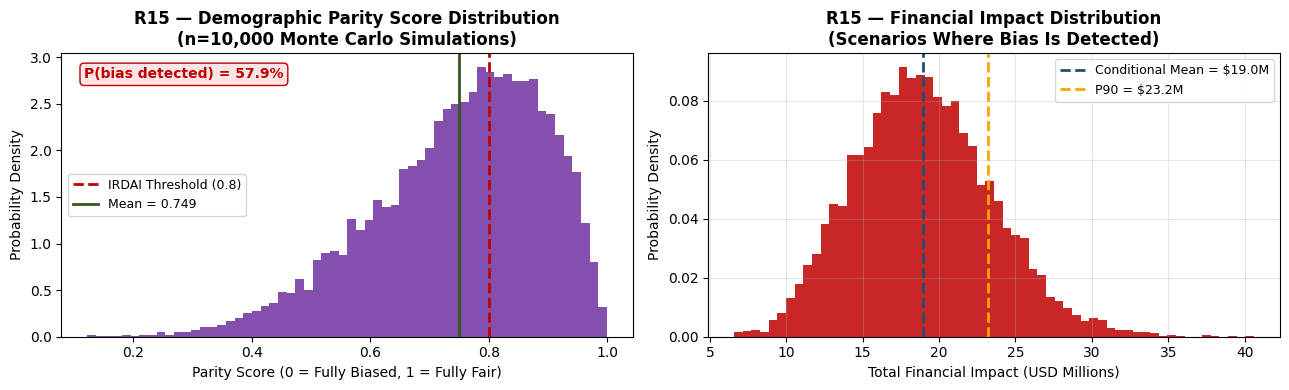

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Parity score distribution
axes[0].hist(parity_score, bins=60, color='#7030A0', edgecolor='none', alpha=0.85, density=True)
axes[0].axvline(IRDAI_THRESHOLD, color='#C00000', lw=2, ls='--', label=f'IRDAI Threshold ({IRDAI_THRESHOLD})')
axes[0].axvline(r15_mean_parity, color='#375623', lw=2, ls='-', label=f'Mean = {r15_mean_parity:.3f}')
axes[0].set_title('R15 — Demographic Parity Score Distribution\n(n=10,000 Monte Carlo Simulations)', fontweight='bold')
axes[0].set_xlabel('Parity Score (0 = Fully Biased, 1 = Fully Fair)')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=9)
axes[0].text(0.04, 0.95, f'P(bias detected) = {r15_prob:.1%}',
             transform=axes[0].transAxes, fontsize=10, color='#C00000',
             va='top', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE5E5', edgecolor='#C00000'))

# Financial impact (non-zero scenarios only)
nonzero = total_impact_r15[total_impact_r15 > 0]
axes[1].hist(nonzero, bins=60, color='#C00000', edgecolor='none', alpha=0.85, density=True)
axes[1].axvline(r15_cond_mean, color='#1F4E79', ls='--', lw=2, label=f'Conditional Mean = ${r15_cond_mean:.1f}M')
axes[1].axvline(r15_p90_impact, color='orange', ls='--', lw=2, label=f'P90 = ${r15_p90_impact:.1f}M')
axes[1].set_title('R15 — Financial Impact Distribution\n(Scenarios Where Bias Is Detected)', fontweight='bold')
axes[1].set_xlabel('Total Financial Impact (USD Millions)')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: Consolidated Quantitative Summary & Dashboard
All results from the Monte Carlo simulations and Random Forest model are consolidated here. This feeds directly into the I&W Analysis Report and the updated Risk Register (RT & RP).

In [12]:
# ── Consolidated Summary Table ──

summary = pd.DataFrame({
    'Risk': ['R1 — Competitor Displacement', 'R9 — Regulatory Delay', 'R15 — AI Bias'],
    'L Score': [7, 7, 7],
    'I Score': [8, 8, 8],
    'Risk Score': [56, 56, 56],
    'ML Severity': ['Medium', 'Medium', 'Medium'],
    'MC Probability': [
        f'{r1_prob:.1%}', f'{r9_prob:.1%}', f'{r15_prob:.1%}'
    ],
    'Mean Exposure ($M)': [
        round(r1_mean_risk, 1), round(r9_mean_exp, 1), round(r15_mean_impact, 1)
    ],
    'P90 Exposure ($M)': [
        round(r1_p90_risk, 1), round(r9_p90_exp, 1), round(r15_p90_impact, 1)
    ],
    'I&W Level': ['🔴 RED', '🟡 AMBER', '🔴 RED']
})

print('=' * 90)
print('  QUANTITATIVE RISK ASSESSMENT SUMMARY — MANULIFE–MAHINDRA JV')
print('  Technique: Monte Carlo Simulation (n=10,000) + Random Forest ML')
print('=' * 90)
print(summary.to_string(index=False))
print('=' * 90)
print('\nKey Takeaways:')
print(f'  • R15 (AI Bias) has the HIGHEST probability at {r15_prob:.1%} — immediate mitigation needed')
print(f'  • R9 (Regulatory Delay) has the HIGHEST mean exposure at USD ${r9_mean_exp:.1f}M')
print(f'  • R1 (Competitor Displacement) has the HIGHEST P90 exposure at USD ${r1_p90_risk:.1f}M')
print('  • All 3 risks classified as MEDIUM by ML — but Monte Carlo reveals material financial exposure')

  QUANTITATIVE RISK ASSESSMENT SUMMARY — MANULIFE–MAHINDRA JV
  Technique: Monte Carlo Simulation (n=10,000) + Random Forest ML
                        Risk  L Score  I Score  Risk Score ML Severity MC Probability  Mean Exposure ($M)  P90 Exposure ($M) I&W Level
R1 — Competitor Displacement        7        8          56      Medium          84.1%                 6.6               14.1     🔴 RED
       R9 — Regulatory Delay        7        8          56      Medium          17.8%                41.2               57.5   🟡 AMBER
               R15 — AI Bias        7        8          56      Medium          57.9%                11.0               23.2     🔴 RED

Key Takeaways:
  • R15 (AI Bias) has the HIGHEST probability at 57.9% — immediate mitigation needed
  • R9 (Regulatory Delay) has the HIGHEST mean exposure at USD $41.2M
  • R1 (Competitor Displacement) has the HIGHEST P90 exposure at USD $14.1M
  • All 3 risks classified as MEDIUM by ML — but Monte Carlo reveals material financi

### Final Comparative Dashboard — All 3 Risks

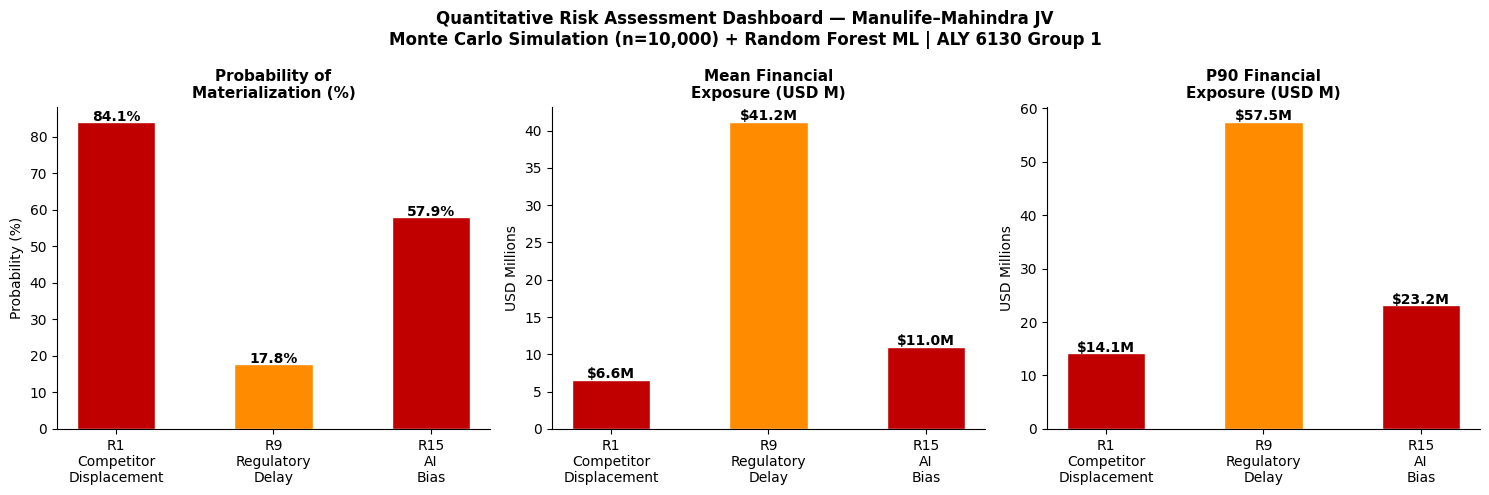

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

risks_labels = ['R1\nCompetitor\nDisplacement', 'R9\nRegulatory\nDelay', 'R15\nAI\nBias']
probs  = [r1_prob*100, r9_prob*100, r15_prob*100]
means  = [r1_mean_risk, r9_mean_exp, r15_mean_impact]
p90s   = [r1_p90_risk, r9_p90_exp, r15_p90_impact]
bar_colors = ['#C00000', '#FF8C00', '#C00000']

for ax, values, title, ylabel, fmt in zip(
    axes,
    [probs, means, p90s],
    ['Probability of\nMaterialization (%)', 'Mean Financial\nExposure (USD M)', 'P90 Financial\nExposure (USD M)'],
    ['Probability (%)', 'USD Millions', 'USD Millions'],
    ['pct', 'usd', 'usd']
):
    bars = ax.bar(risks_labels, values, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, values):
        label = f'{val:.1f}%' if fmt == 'pct' else f'${val:.1f}M'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                label, ha='center', fontweight='bold', fontsize=10)

plt.suptitle(
    'Quantitative Risk Assessment Dashboard — Manulife–Mahindra JV\n'
    'Monte Carlo Simulation (n=10,000) + Random Forest ML | ALY 6130 Group 1',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Step 9: Three-Dimensional Risk Prioritization

**Methodological Reference:** Jalilvand & Moorthy (2023), *JRFM*, 16:473

Extends the 2D risk score by adding Control Level (RIMS RMM 5-point scale).
Data flows from `df` loaded in Step 2 — no hardcoding.

| Control | RIMS Label | Definition |
|:---:|---|---|
| 1 | Ad hoc | Improvised, no formal process |
| 2 | Initial | Siloed, no integration |
| 3 | Repeatable | Established framework |
| 4 | Managed | Enterprise-wide harmonized |
| 5 | Leadership | Embedded in strategy |

In [14]:
RIMS_LABELS = {1:'Ad hoc',2:'Initial',3:'Repeatable',4:'Managed',5:'Leadership'}

control_levels = {
    1:3,2:3,3:4,4:3,5:4,6:3,7:2,8:2,
    9:4,10:3,11:4,12:3,13:3,14:3,15:4,16:3,
    17:2,18:3,19:4,20:3,21:4,22:4,23:4,24:4,
    25:3,26:4,27:3,28:3,29:3,30:3,31:3,32:4
}
category_map = {
    1:'Competitive',2:'Competitive',3:'Competitive',
    4:'Financial',5:'Financial',6:'Financial',7:'Financial',8:'Financial',
    9:'Operational',10:'Operational',11:'Operational',12:'Operational',13:'Operational',14:'Operational',
    15:'Technology/AI',16:'Technology/AI',17:'Technology/AI',18:'Technology/AI',19:'Technology/AI',20:'Technology/AI',
    21:'Info Security',22:'Info Security',23:'Info Security',24:'Info Security',
    25:'Legal/Compliance',26:'Legal/Compliance',27:'Legal/Compliance',28:'Legal/Compliance',
    29:'Reputational',30:'Reputational',31:'Reputational',32:'Reputational'
}

df_3d = df[['Risk_ID','Risk_Description','Likelihood_Score','Impact_Score','Risk_Score','Severity']].copy()
df_3d.columns = ['Risk_ID','Name','Likelihood','Impact','Score','Priority_Label']
df_3d['Control'] = df_3d['Risk_ID'].map(control_levels)
df_3d['Control_Label'] = df_3d['Control'].map(RIMS_LABELS)
df_3d['Category'] = df_3d['Risk_ID'].map(category_map)
df_3d['EI_Index'] = df_3d['Likelihood'] * df_3d['Impact']
df_3d['CA_Index'] = df_3d['EI_Index'] / df_3d['Control']
df_3d['Priority'] = df_3d['Score'].apply(lambda s: 'HIGH' if s>=45 else ('MEDIUM' if s>=20 else 'LOW'))
df_3d['EI_Rank'] = df_3d['EI_Index'].rank(ascending=False,method='min').astype(int)
df_3d['CA_Rank'] = df_3d['CA_Index'].rank(ascending=False,method='min').astype(int)
df_3d['Avg_Rank'] = (df_3d['EI_Rank'] + df_3d['CA_Rank']) / 2
df_3d['Composite_Rank'] = df_3d['Avg_Rank'].rank(ascending=True,method='min').astype(int)
df_3d_sorted = df_3d.sort_values('Composite_Rank').reset_index(drop=True)

print('='*90)
print('THREE-DIMENSIONAL PRIORITY RANKING — Top 15')
print('='*90)
print(df_3d_sorted[['Composite_Rank','Risk_ID','Name','Category',
                     'Likelihood','Impact','Score','Control','Control_Label',
                     'EI_Rank','CA_Rank']].head(15).to_string(index=False))
print('='*90)

THREE-DIMENSIONAL PRIORITY RANKING — Top 15
 Composite_Rank  Risk_ID                                             Name         Category  Likelihood  Impact  Score  Control Control_Label  EI_Rank  CA_Rank
              1        3      Regulatory Tailwinds Opportunity (Positive)      Competitive           9       9     81        4       Managed        1        1
              2        1            LIC & Private Competitor Displacement      Competitive           7       8     56        3    Repeatable        2        2
              2       18 Global AI Competition Setting Industry Standards    Technology/AI           7       8     56        3    Repeatable        2        2
              4       15        AI Underwriting Bias — Rural Demographics    Technology/AI           7       8     56        4       Managed        2        7
              4       26        AI Transparency & Explainability Conflict Legal/Compliance           7       8     56        4       Managed        2        7
  

### Step 9 — Visualization: Control Level Distribution & Composite Ranking


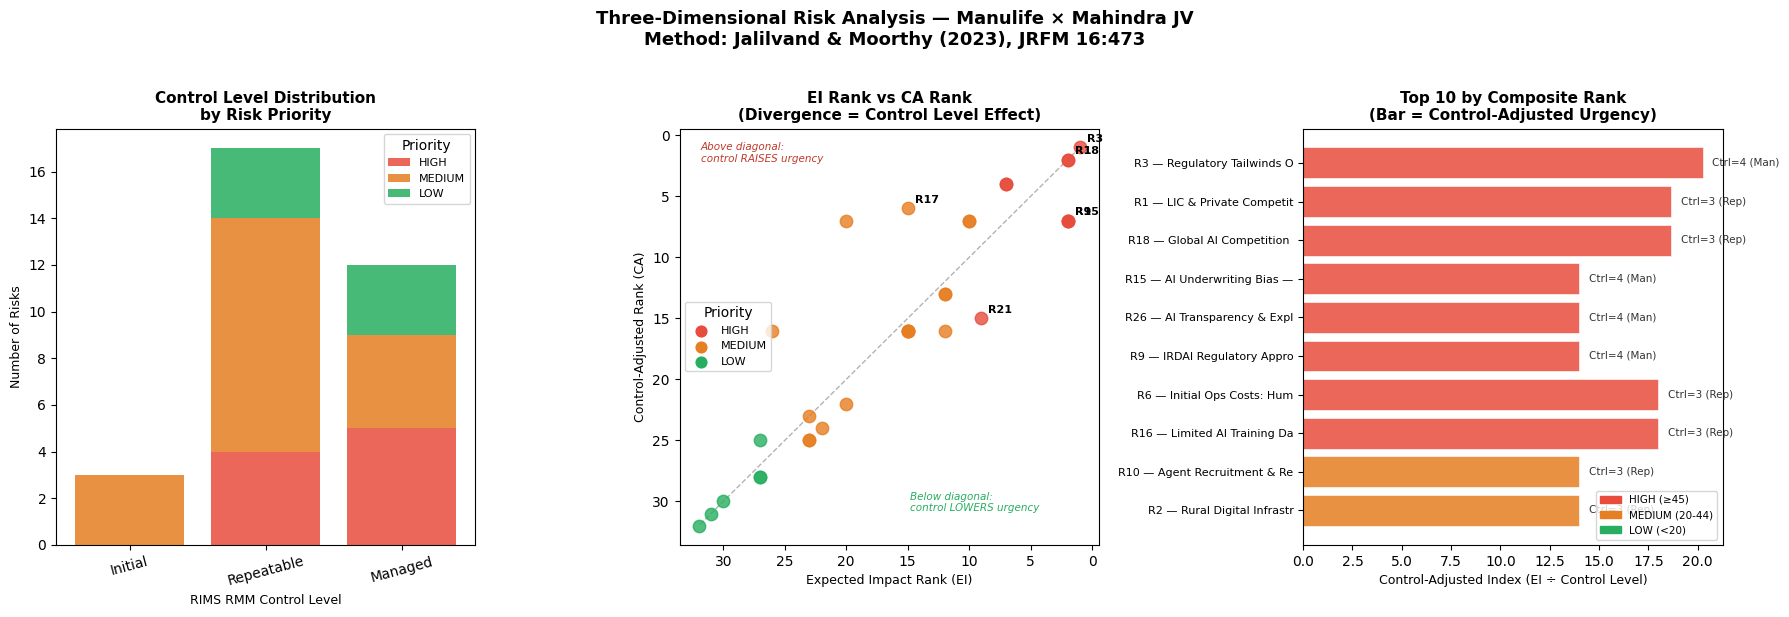

Chart saved: 3D_Risk_Analysis.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Three-Dimensional Risk Analysis — Manulife × Mahindra JV\n'
             'Method: Jalilvand & Moorthy (2023), JRFM 16:473',
             fontsize=13, fontweight='bold', y=1.02)

# ── Chart 1: Control Level distribution by Priority ──
ax1 = axes[0]
ctrl_priority = df_3d.groupby(['Control_Label', 'Priority']).size().unstack(fill_value=0)
ctrl_order = ['Ad hoc', 'Initial', 'Repeatable', 'Managed', 'Leadership']
ctrl_priority = ctrl_priority.reindex([c for c in ctrl_order if c in ctrl_priority.index])
colors_priority = {'HIGH': '#E74C3C', 'MEDIUM': '#E67E22', 'LOW': '#27AE60'}
bottom = np.zeros(len(ctrl_priority))
for priority in ['HIGH', 'MEDIUM', 'LOW']:
    if priority in ctrl_priority.columns:
        vals = ctrl_priority[priority].values
        ax1.bar(ctrl_priority.index, vals, bottom=bottom,
                color=colors_priority[priority], label=priority, alpha=0.85)
        bottom += vals
ax1.set_title('Control Level Distribution\nby Risk Priority', fontsize=11, fontweight='bold')
ax1.set_xlabel('RIMS RMM Control Level', fontsize=9)
ax1.set_ylabel('Number of Risks', fontsize=9)
ax1.legend(title='Priority', fontsize=8)
ax1.tick_params(axis='x', rotation=15)

# ── Chart 2: EI Rank vs CA Rank scatter (divergence = control effect) ──
ax2 = axes[1]
colors_map = {'HIGH': '#E74C3C', 'MEDIUM': '#E67E22', 'LOW': '#27AE60'}
for _, row in df_3d.iterrows():
    c = colors_map[row['Priority']]
    ax2.scatter(row['EI_Rank'], row['CA_Rank'], color=c, s=80, alpha=0.8, zorder=3)
    if row['Risk_ID'] in [1, 9, 15, 17, 18, 3, 21]:
        ax2.annotate(f"R{int(row['Risk_ID'])}",
                     (row['EI_Rank'], row['CA_Rank']),
                     textcoords='offset points', xytext=(5, 4), fontsize=8, fontweight='bold')
# Diagonal: EI rank = CA rank (no control effect)
ax2.plot([1, 32], [1, 32], 'k--', alpha=0.3, linewidth=1, label='No control effect')
ax2.set_title('EI Rank vs CA Rank\n(Divergence = Control Level Effect)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Expected Impact Rank (EI)', fontsize=9)
ax2.set_ylabel('Control-Adjusted Rank (CA)', fontsize=9)
ax2.invert_xaxis(); ax2.invert_yaxis()
legend_handles = [plt.scatter([], [], color=c, s=60, label=p)
                  for p, c in colors_map.items()]
ax2.legend(handles=legend_handles, title='Priority', fontsize=8)
ax2.annotate('Above diagonal:\ncontrol RAISES urgency',
             xy=(0.05, 0.92), xycoords='axes fraction', fontsize=7.5,
             color='#C0392B', style='italic')
ax2.annotate('Below diagonal:\ncontrol LOWERS urgency',
             xy=(0.55, 0.08), xycoords='axes fraction', fontsize=7.5,
             color='#27AE60', style='italic')

# ── Chart 3: Composite rank — Top 10 horizontal bar ──
ax3 = axes[2]
top10 = df_3d_sorted.head(10).copy()
labels = [f"R{row.Risk_ID} — {row.Name[:22]}" for _, row in top10.iterrows()]
bar_colors = ['#E74C3C' if s >= 45 else '#E67E22' if s >= 20 else '#27AE60'
              for s in top10['Score']]
bars = ax3.barh(range(len(top10)), top10['CA_Index'],
                color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax3.set_yticks(range(len(top10)))
ax3.set_yticklabels(labels, fontsize=8)
ax3.invert_yaxis()
ax3.set_xlabel('Control-Adjusted Index (EI ÷ Control Level)', fontsize=9)
ax3.set_title('Top 10 by Composite Rank\n(Bar = Control-Adjusted Urgency)', fontsize=11, fontweight='bold')
for i, (bar, row) in enumerate(zip(bars, top10.itertuples())):
    ax3.text(bar.get_width() + 0.5, i,
             f'Ctrl={row.Control} ({row.Control_Label[:3]})',
             va='center', fontsize=7.5, color='#333333')
from matplotlib.patches import Patch
legend_e = [Patch(color='#E74C3C', label='HIGH (≥45)'),
            Patch(color='#E67E22', label='MEDIUM (20-44)'),
            Patch(color='#27AE60', label='LOW (<20)')]
ax3.legend(handles=legend_e, fontsize=7.5, loc='lower right')

plt.tight_layout()
plt.savefig('3D_Risk_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: 3D_Risk_Analysis.png')


## Step 10: Risk Heat Maps — Standard (2D) and Three-Dimensional (Control Overlay)

Two heat maps are produced using the **actual 1–9 scale** from the Risk Calculation Sheet
(not a normalized 1–5 scale). Likelihood and Impact values map to:

| Score | Likelihood Label | Impact Label |
|:---:|---|---|
| 1 | Very Unlikely | Very Low |
| 3 | Somewhat Unlikely | Somewhat Low |
| 5 | 50-50 Possibility | Moderate |
| 7 | Somewhat Likely | Somewhat High |
| 9 | Very Likely | High / Extremely High |

**Priority thresholds (from Risk Calculation Sheet):**
- 🔴 **HIGH**: Score ≥ 45
- 🟠 **MEDIUM**: Score 20–44
- 🟢 **LOW**: Score < 20


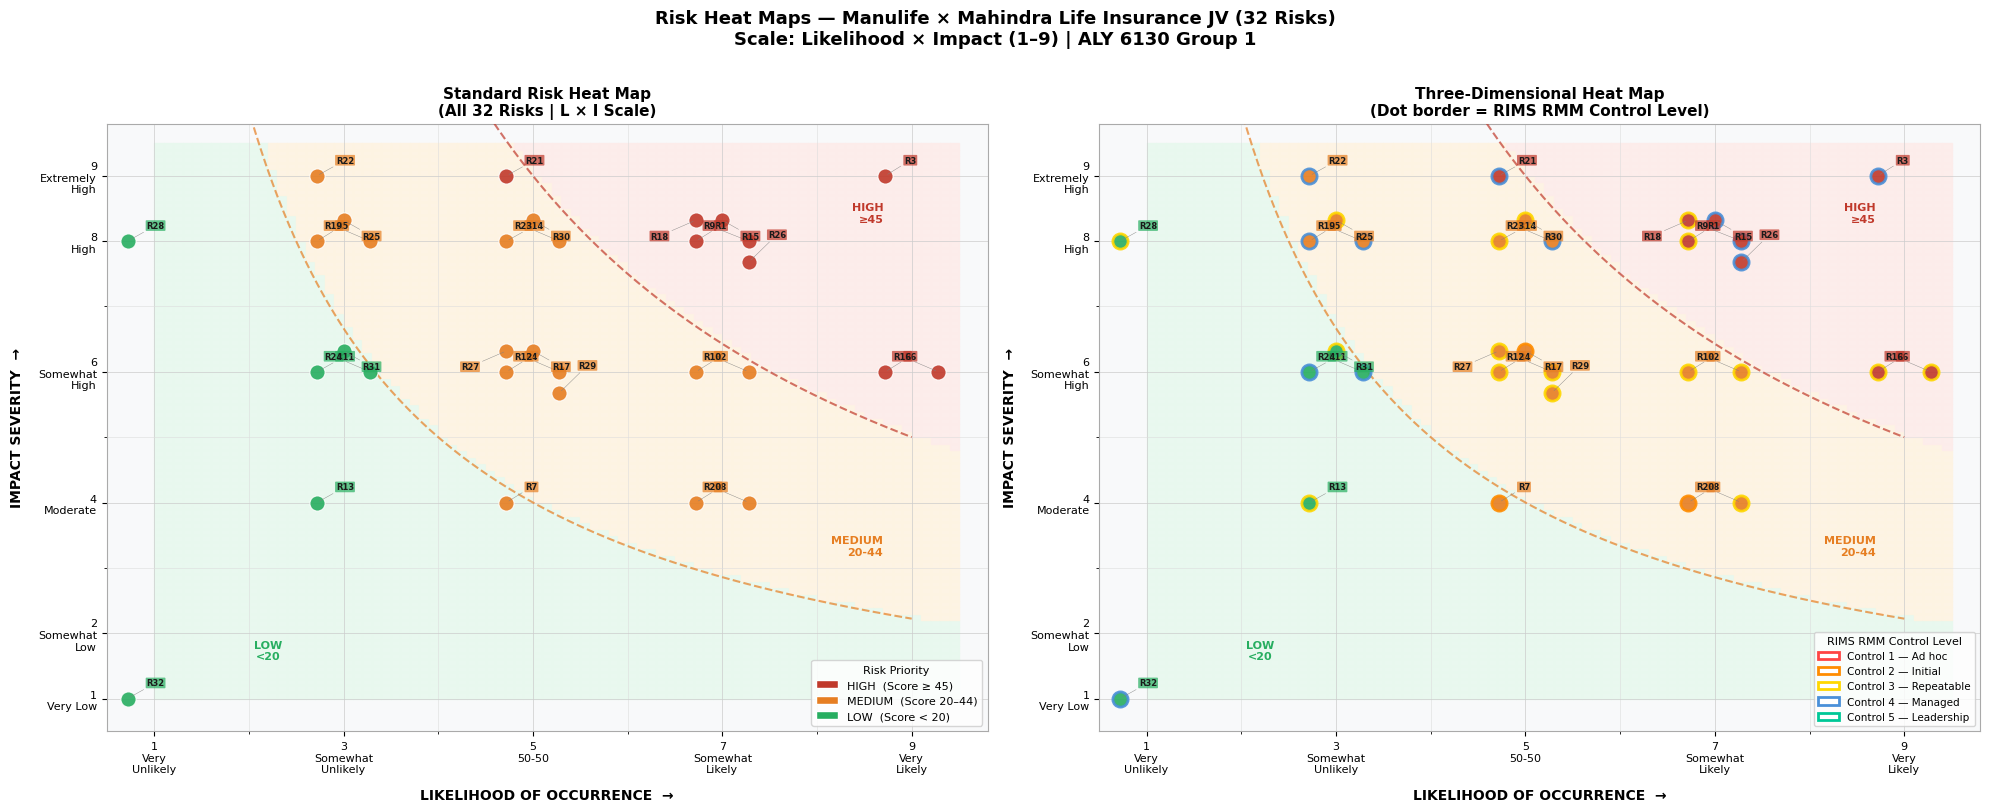

Heat maps saved: Risk_HeatMaps.png


In [17]:
from collections import defaultdict
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Risk Heat Maps — Manulife × Mahindra Life Insurance JV (32 Risks)\n'
             'Scale: Likelihood × Impact (1–9) | ALY 6130 Group 1',
             fontsize=13, fontweight='bold', y=1.01)

HIGH_T, MED_T = 45, 20
lvals = np.linspace(1, 9, 400)

def get_zone_color(score):
    return '#C0392B' if score >= HIGH_T else '#E67E22' if score >= MED_T else '#27AE60'

CTRL_COLORS = {1:'#FF4444', 2:'#FF8C00', 3:'#FFD700', 4:'#4A90D9', 5:'#00C897'}

# Prepare risk data for plotting
risk_3d_data = df_3d[['Risk_ID', 'Name', 'Category', 'Likelihood', 'Impact', 'Score', 'Control']].values.tolist()

for ax_idx, ax in enumerate(axes):
    ax.set_facecolor('#F8F9FA')

    # Background heat zones
    for l in np.arange(1, 9.5, 0.1):
        for i in np.arange(1, 9.5, 0.1):
            s = l * i
            c = '#FDECEA' if s >= HIGH_T else '#FEF3E2' if s >= MED_T else '#E8F8EE'
            ax.fill_between([l, l+0.1], [i, i], [i+0.1, i+0.1], color=c, alpha=0.9)

    ax.plot(lvals, HIGH_T/lvals, color='#C0392B', lw=1.5, ls='--', alpha=0.7, zorder=3)
    ax.plot(lvals, MED_T/lvals,  color='#E67E22', lw=1.5, ls='--', alpha=0.7, zorder=3)
    ax.text(8.7, 8.3, 'HIGH\n≥45',     color='#C0392B', fontsize=8, fontweight='bold', ha='right', zorder=4)
    ax.text(8.7, 3.2, 'MEDIUM\n20-44', color='#E67E22', fontsize=8, fontweight='bold', ha='right', zorder=4)
    ax.text(2.2, 1.6, 'LOW\n<20',      color='#27AE60', fontsize=8, fontweight='bold', ha='center',zorder=4)

    # Plot risks
    position_count = defaultdict(int)
    for r in risk_3d_data:
        rid, name, cat, lk, im, sc, ctrl = r
        key = (lk, im)
        offset = position_count[key]
        position_count[key] += 1
        jx = [-0.28, 0.28,  0.00, -0.28,  0.28,  0.00][offset % 6]
        jy = [ 0.00, 0.00,  0.32,  0.32, -0.32, -0.32][offset % 6]
        px, py = lk + jx, im + jy

        dot_fc = get_zone_color(sc)
        edge_c = CTRL_COLORS[ctrl] if ax_idx == 1 else 'white'
        lw     = 2.0 if ax_idx == 1 else 0.8

        ax.scatter(px, py, s=120, color=dot_fc, edgecolors=edge_c,
                   linewidths=lw, zorder=10, alpha=0.9)
        lox_opts = [(0.20,0.20),(-0.48,0.20),(0.20,-0.28),(-0.48,-0.28),(0.20,0.38),(-0.48,0.38)]
        lox, loy = lox_opts[offset % 6]
        ax.annotate(f'R{rid}', xy=(px,py), xytext=(px+lox, py+loy),
                    fontsize=6, fontweight='bold', color='#1a1a1a', zorder=11,
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.3),
                    bbox=dict(boxstyle='round,pad=0.1', facecolor=dot_fc,
                              alpha=0.7, edgecolor='none'))

    ax.set_xlim(0.5, 9.8); ax.set_ylim(0.5, 9.8)
    ax.set_xticks([1,3,5,7,9])
    ax.set_xticklabels(['1\nVery\nUnlikely','3\nSomewhat\nUnlikely',
                        '5\n50-50','7\nSomewhat\nLikely','9\nVery\nLikely'], fontsize=8)
    ax.set_yticks([1,2,4,6,8,9])
    ax.set_yticklabels(['1\nVery Low','2\nSomewhat\nLow','4\nModerate',
                        '6\nSomewhat\nHigh','8\nHigh','9\nExtremely\nHigh'], fontsize=8)
    ax.set_xticks(range(1,10), minor=True); ax.set_yticks(range(1,10), minor=True)
    ax.grid(which='minor', color='#DDDDDD', lw=0.4)
    ax.grid(which='major', color='#CCCCCC', lw=0.5)
    ax.set_xlabel('LIKELIHOOD OF OCCURRENCE  →', fontsize=10, fontweight='bold', labelpad=10)
    ax.set_ylabel('IMPACT SEVERITY  →', fontsize=10, fontweight='bold', labelpad=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#AAAAAA')

# Left: standard heat map
axes[0].set_title('Standard Risk Heat Map\n(All 32 Risks | L × I Scale)', fontsize=11, fontweight='bold')
zone_legend = [mpatches.Patch(fc='#C0392B', ec='white', label='HIGH  (Score ≥ 45)'),
               mpatches.Patch(fc='#E67E22', ec='white', label='MEDIUM  (Score 20–44)'),
               mpatches.Patch(fc='#27AE60', ec='white', label='LOW  (Score < 20)')]
axes[0].legend(handles=zone_legend, loc='lower right', fontsize=8,
               title='Risk Priority', title_fontsize=8)

# Right: 3D heat map with control border
axes[1].set_title('Three-Dimensional Heat Map\n(Dot border = RIMS RMM Control Level)', fontsize=11, fontweight='bold')
ctrl_legend = [mpatches.Patch(fc='white', ec=CTRL_COLORS[k], linewidth=2,
               label=f'Control {k} — {RIMS_LABELS[k]}') for k in range(1,6)]
axes[1].legend(handles=ctrl_legend, loc='lower right', fontsize=7.5,
               title='RIMS RMM Control Level', title_fontsize=8)

plt.tight_layout()
plt.savefig('Risk_HeatMaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heat maps saved: Risk_HeatMaps.png')